In [1]:
!pwd

/truejit/evaluation/smartjit


In [3]:
from Profiling import StaticCompiler

sc = StaticCompiler()

-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found Boost: /usr/local/lib/cmake/Boost-1.84.0/BoostConfig.cmake (found suitable version "1.84.0", minimum required is "1.84") found components: timer thread system
-- Found nlohmann_json: /usr/local/share/cmake/nlohmann_json/nlohmann_jsonConfig.cmake (found version "3.11.3")
-- Performing Test HAVE_FFI_CALL
-- Performing Test HAVE_FFI_CALL - Success
-- Found FFI: /usr/lib/x86_64-linux-gnu/libffi.so
-- Could NOT find LibEdit (missing: LibEdit_INCLUDE_DIRS LibEdit_LIBRARIES) 
-- Performin

CMake Warning at compiler/compilation-service/_deps/corrosion-src/cmake/CorrosionGenerator.cmake:95 (message):
  Failed to import Rust crate cranelift_compiler (kind: `[ "bin" ]`) because
  a target with the same name already exists.  Skipping this target.

  Help: If you are importing a package which exposes both a `lib` and a `bin`
  target, please consider explicitly naming the targets in your `Cargo.toml`
  manifest.

  Note: If you have multiple different packages which have targets with the
  same name, please note that this is currently not supported by Corrosion.
  Feel free to open an issue on Github to request supporting this scenario.
Call Stack (most recent call first):
  compiler/compilation-service/_deps/corrosion-src/cmake/CorrosionGenerator.cmake:278 (_generator_add_package_targets)
  compiler/compilation-service/_deps/corrosion-src/cmake/Corrosion.cmake:1044 (_generator_add_cargo_targets)
  lib/Compiler/CraneliftCompiler/CMakeLists.txt:9 (corrosion_import_crate)




In [2]:
from mibench.suite import mibench
from spec.suite import spec
from coremark.benchmark import coremark
from ffmpeg.benchmark import ffmpeg
from sqlite.benchmark import sqlite
from jetstream.suite import jetstream
from polybench.suite import suite as polybench
from npb.suite import suite as npb
from wabench.suite import wabench

all_benchmarks = []
all_benchmarks.extend(jetstream.benchmarks)
all_benchmarks.extend([sqlite])
all_benchmarks.extend(mibench.benchmarks)
all_benchmarks.extend(spec.benchmarks)
all_benchmarks.extend(npb('S').benchmarks)
all_benchmarks.extend(wabench.benchmarks)
all_benchmarks.extend([coremark])
all_benchmarks.extend(polybench('standard').benchmarks)
all_benchmarks.extend([ffmpeg])

In [20]:
sizes = {}
for b in all_benchmarks:
    sc.compile(b, ['--compiler=llvm.o3.ext'])
    # print the size of the directory containing the benchmark
    bin_dir = str(b.binary.parent)
    # replace '/benchmarks/' with '/binaries/'
    bin_dir = bin_dir.replace('benchmarks', 'binaries')

    sizes[bin_dir] = sum([f.stat().st_size for f in b.binary.parent.glob('*.o')])

    # print the size of the binary
    print(f'{b.mode:20} {sizes[bin_dir]:10} {b.binary}')


Binary directory: /truejit/binaries/jetstream/float_mm
[static-compiler][result] compilation=4.6 (seconds)       
float-mm                      0 /truejit/benchmarks/jetstream/float_mm/float-mm.wasm
Binary directory: /truejit/binaries/jetstream/gcc_loops
[static-compiler][result] compilation=43.0 (seconds)      
gcc-loops                     0 /truejit/benchmarks/jetstream/gcc_loops/gcc-loops.wasm
Binary directory: /truejit/binaries/jetstream/hashset
[static-compiler][result] compilation=15.7 (seconds)      
hashset                       0 /truejit/benchmarks/jetstream/hashset/hashset.wasm
Binary directory: /truejit/binaries/jetstream/quicksort
[static-compiler][result] compilation=2.5 (seconds)       
quicksort                     0 /truejit/benchmarks/jetstream/quicksort/quicksort.wasm
Binary directory: /truejit/binaries/jetstream/tsf
[static-compiler][result] compilation=27.1 (seconds)      
tsf                           0 /truejit/benchmarks/jetstream/tsf/tsf.wasm
Binary directory:

In [3]:
from pathlib import Path

sizes = []
for b in all_benchmarks:
    bin_dir = str(b.binary.parent)
    bin_dir = bin_dir.replace('benchmarks', 'binaries')

    # size is sum of all .o files in bin_dir
    size = sum([f.stat().st_size for f in Path(bin_dir).glob('*.o')])
    sizes.append(size)
    print(f'{b.mode:20} {size / 1000:10} KB {b.binary.stat().st_size / 1000:10} KB')

print(f'Total size: {sum(sizes) / 1000_000} MB')

float-mm                 57.976 KB     20.548 KB
gcc-loops               831.064 KB   2412.587 KB
hashset                 486.328 KB    385.207 KB
quicksort                  58.8 KB     19.906 KB
tsf                     834.304 KB    480.483 KB
SQLite                   4180.6 KB   2897.179 KB
basicmath               110.104 KB     79.233 KB
bitcount                 87.224 KB     41.625 KB
stringsearch             57.928 KB     34.853 KB
cjpeg                   451.776 KB    161.079 KB
djpeg                   447.776 KB    168.852 KB
rawcaudio                58.184 KB     20.218 KB
rawdaudio                 58.12 KB     20.144 KB
blowfish-encode          82.952 KB     37.089 KB
blowfish-decode          82.952 KB     37.089 KB
rijndael-encode         127.248 KB     78.471 KB
rijndael-decode         127.248 KB     78.471 KB
crc32                   107.296 KB     44.062 KB
sha                     109.272 KB     44.026 KB
lbm                     172.992 KB     71.885 KB
mcf                 

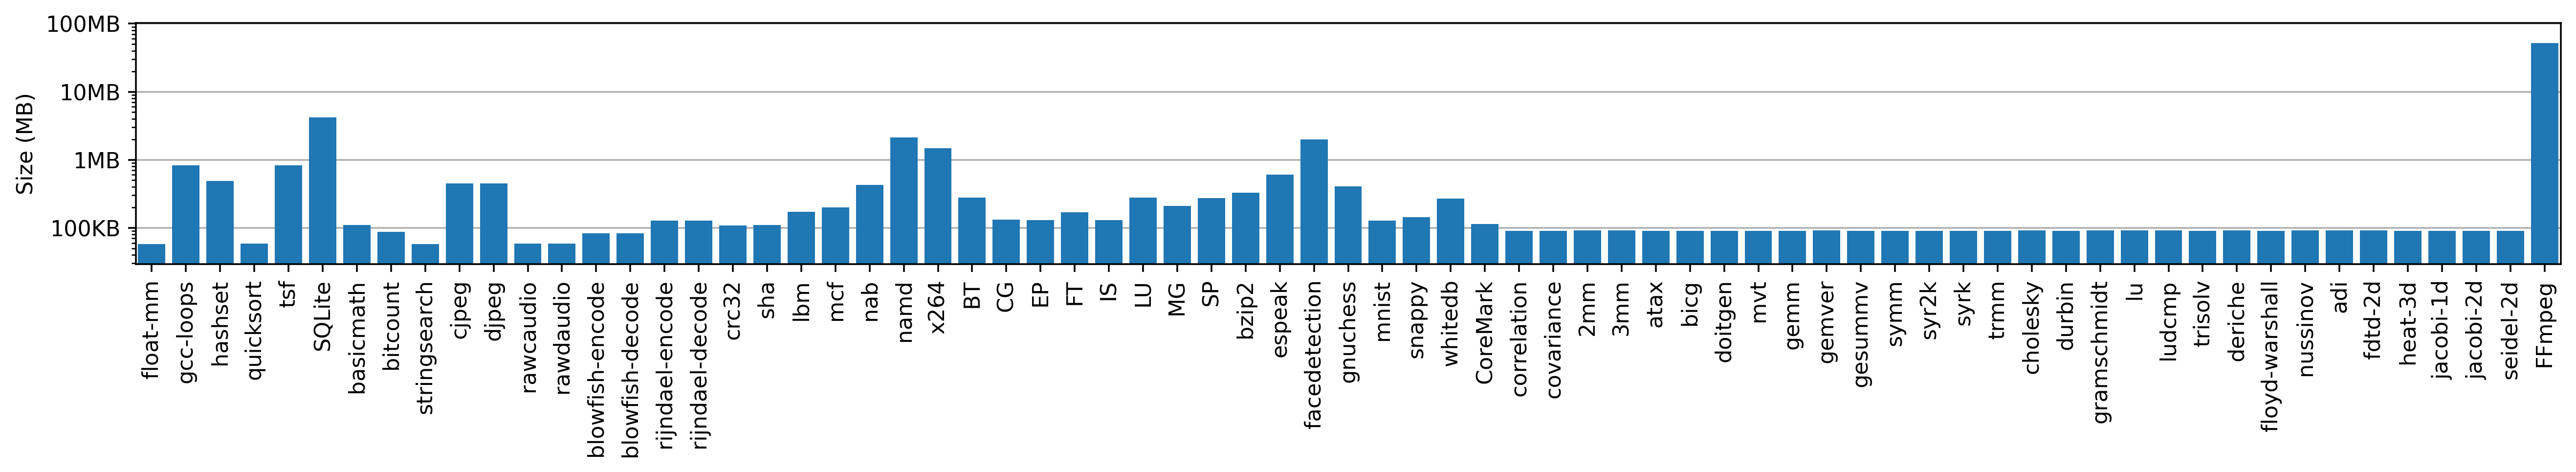

In [16]:
# use matplotlib to plot the sizes for each benchmark
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 2), dpi=320)
plt.bar([b.mode for b in all_benchmarks], sizes)
plt.xticks(rotation=90)
plt.ylabel('Size (MB)')
# y is in MB, from 0 to 100
# plt.ylim(0, 60_000_000)

# log scale for y axis
plt.yscale('log')

# show 100KB, 1MB, 10MB, 100MB
plt.yticks([100_000, 1_000_000, 10_000_000, 100_000_000], ['100KB', '1MB', '10MB', '100MB'])

# print grid, push grid to the background
plt.grid(axis='y')
plt.gca().set_axisbelow(True)

# margin
plt.margins(0.001, 0.1)

plt.show()
